# RFI Band Analysis — Interference Impact Across Frequency Bands


In [1]:
import os
import sys
import matplotlib.pyplot as plt

#
_cwd = os.getcwd()
_root = os.path.dirname(_cwd) if os.path.basename(_cwd) == "notebooks" else _cwd
if _root not in sys.path:
    sys.path.insert(0, _root)

from rfi.scenario import (
    run_multi_entry_rfi_scenario,
    VICTIM_BANDS,
    INTERFERENCE_SCENARIOS,
    FREQUENCY_SWEEP_POINTS,
)

TIME_SAMPLES = 5000
BAND_NAMES = list(VICTIM_BANDS.keys())

# Plot
FIG_SIZE = (9, 5)
BAR_COLORS = ["#DCEEFF","#A8D0FF","#5FA8F5","#2F7FD8","#174A8B"]
AXES_FONTSIZE = 12
TITLE_FONTSIZE = 14
VALUE_FONTSIZE = 10

In [2]:
def plot_bar(band_names, values, ylabel, title):
    fig, ax = plt.subplots(figsize=FIG_SIZE)
    ax.bar(band_names, values, color=BAR_COLORS, edgecolor="black", linewidth=0.6)
    ax.set_xlabel("Frequency Band", fontsize=AXES_FONTSIZE)
    ax.set_ylabel(ylabel, fontsize=AXES_FONTSIZE)
    ax.set_title(title, fontsize=TITLE_FONTSIZE, fontweight="bold")
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    ax.set_ylim(0, max(values) * 1.2 if values else 1)
    plt.tight_layout()
    plt.show()


def print_table(title, header_row, data_rows):
    print(title)
    sep = "-" * max(62, len(header_row))
    print(sep)
    print(header_row)
    print(sep)
    for row in data_rows:
        print(row)
    print(sep)
    print()

## Plot 1 — Baseline SNR (No Interference)

Plot 1 — Baseline SNR
--------------------------------------------------------------
Band       |  Baseline SNR (dB)
--------------------------------------------------------------
S-band     |              20.37
X-band     |              20.37
Ku-band    |              20.37
K-band     |              20.37
Ka-band    |              20.37
--------------------------------------------------------------



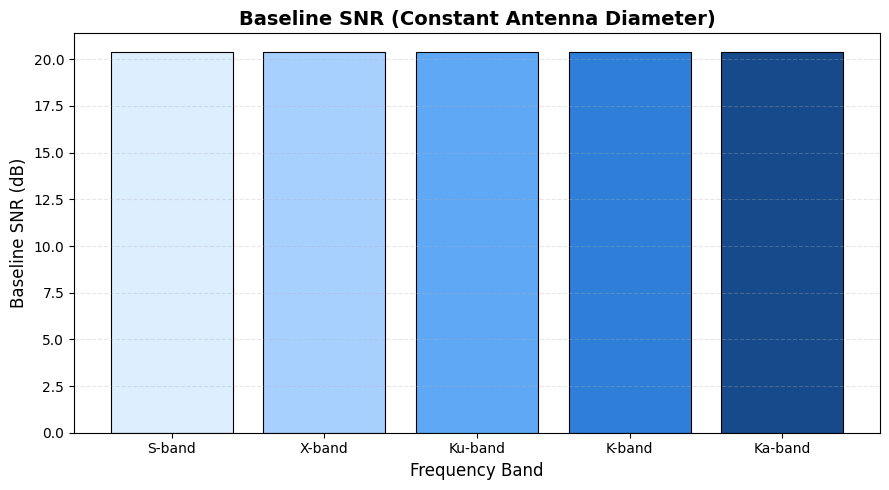

In [3]:
baseline_snr = []

for band in BAND_NAMES:
    params = VICTIM_BANDS[band].copy()
    params["band_name"] = band

    res = run_multi_entry_rfi_scenario(
        band_params=params,
        interferer_list=INTERFERENCE_SCENARIOS["Strong"],
        time_sim_samples=TIME_SAMPLES,
    )
    baseline_snr.append(res["Baseline SNR (dB)"])

print_table(
    "Plot 1 — Baseline SNR",
    f"{'Band':<10} | {'Baseline SNR (dB)':>18}",
    [f"{band:<10} | {snr:>18.2f}" for band, snr in zip(BAND_NAMES, baseline_snr)],
)

# Create figure
fig, ax = plt.subplots(figsize=FIG_SIZE)

ax.bar(BAND_NAMES, baseline_snr, color=BAR_COLORS, edgecolor="black", linewidth=0.8)

ax.set_xlabel("Frequency Band", fontsize=AXES_FONTSIZE)
ax.set_ylabel("Baseline SNR (dB)", fontsize=AXES_FONTSIZE)
ax.set_title("Baseline SNR (Constant Antenna Diameter)", fontsize=TITLE_FONTSIZE, fontweight="bold")

ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()

## Save figures
#fig.savefig("plot1_baseline_snr.pdf", bbox_inches="tight")
#fig.savefig("plot1_baseline_snr.png", dpi=600, bbox_inches="tight")

plt.show()

---
## Plot 2 — Weak Interference (ΔSNR)

Single interferer, weak EIRP

Plot 2 — Weak Interference (Constant D)
--------------------------------------------------------------
Band       |  ΔSNR (dB) |   C/I (dB)
--------------------------------------------------------------
S-band     |       0.30 |      31.79
X-band     |       0.21 |      33.50
Ku-band    |       0.12 |      35.88
K-band     |       0.04 |      40.36
Ka-band    |       0.01 |      47.71
--------------------------------------------------------------



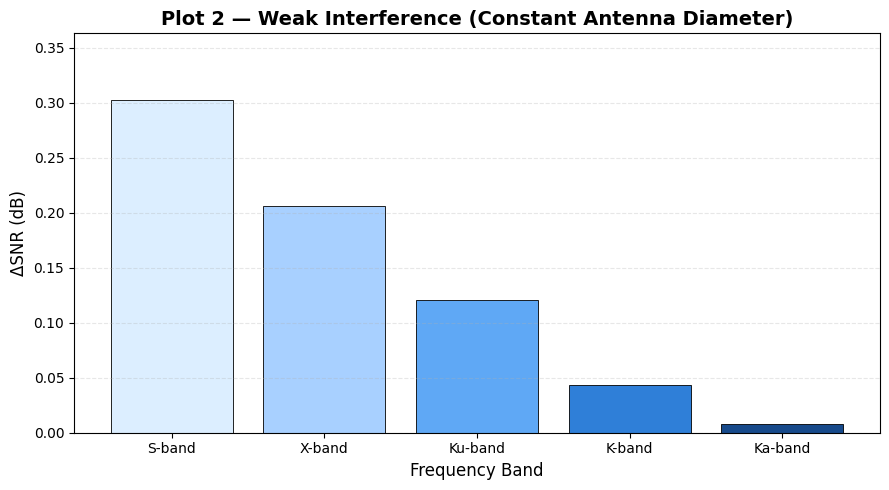

In [4]:
results_weak = []

for band in BAND_NAMES:
    params = VICTIM_BANDS[band].copy()
    params["band_name"] = band

    res = run_multi_entry_rfi_scenario(
        band_params=params,
        interferer_list=INTERFERENCE_SCENARIOS["Weak"],
        time_sim_samples=TIME_SAMPLES,
    )
    results_weak.append(res)

snr_loss_weak = [r["SNR Loss (dB)"] for r in results_weak]

print_table(
    "Plot 2 — Weak Interference (Constant D)",
    f"{'Band':<10} | {'ΔSNR (dB)':>10} | {'C/I (dB)':>10}",
    [
        f"{band:<10} | {r['SNR Loss (dB)']:>10.2f} | {r['C/I_Aggregate (dB)']:>10.2f}"
        for band, r in zip(BAND_NAMES, results_weak)
    ],
)

plot_bar(
    BAND_NAMES,
    snr_loss_weak,
    "ΔSNR (dB)",
    "Plot 2 — Weak Interference (Constant Antenna Diameter)",
)

---
## Plot 3 — Moderate Interference (ΔSNR)

Single interferer, moderate EIRP. Same geometry and bands; only interference strength changes.

Plot 3 — Moderate Interference (Constant D)
--------------------------------------------------------------
Band       |  ΔSNR (dB) |   C/I (dB)
--------------------------------------------------------------
S-band     |       2.36 |      21.79
X-band     |       1.72 |      23.50
Ku-band    |       1.08 |      25.88
K-band     |       0.42 |      30.36
Ka-band    |       0.08 |      37.71
--------------------------------------------------------------



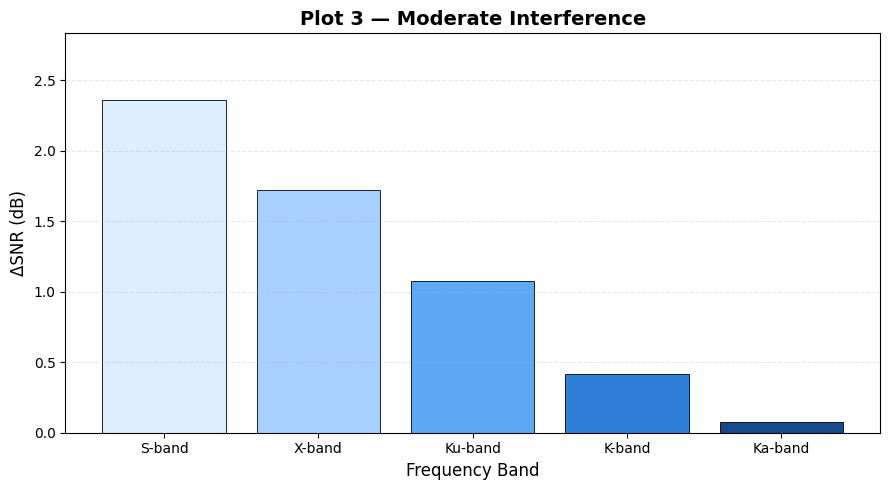

In [5]:
results_moderate = []

for band in BAND_NAMES:
    params = VICTIM_BANDS[band].copy()
    params["band_name"] = band

    res = run_multi_entry_rfi_scenario(
        band_params=params,
        interferer_list=INTERFERENCE_SCENARIOS["Moderate"],
        time_sim_samples=TIME_SAMPLES,
    )
    results_moderate.append(res)

snr_loss_moderate = [r["SNR Loss (dB)"] for r in results_moderate]

print_table(
    "Plot 3 — Moderate Interference (Constant D)",
    f"{'Band':<10} | {'ΔSNR (dB)':>10} | {'C/I (dB)':>10}",
    [
        f"{band:<10} | {r['SNR Loss (dB)']:>10.2f} | {r['C/I_Aggregate (dB)']:>10.2f}"
        for band, r in zip(BAND_NAMES, results_moderate)
    ],
)

plot_bar(
    BAND_NAMES,
    snr_loss_moderate,
    "ΔSNR (dB)",
    "Plot 3 — Moderate Interference",
)

---
## Plot 4 — Strong Interference (ΔSNR)

Single interferer, strong EIRP. Completes the progressive interference severity sweep.

Plot 4 — Strong Interference (Constant D)
--------------------------------------------------------------
Band       |  ΔSNR (dB) |   C/I (dB)
--------------------------------------------------------------
S-band     |       9.15 |      11.79
X-band     |       7.68 |      13.50
Ku-band    |       5.81 |      15.88
K-band     |       3.02 |      20.36
Ka-band    |       0.74 |      27.71
--------------------------------------------------------------



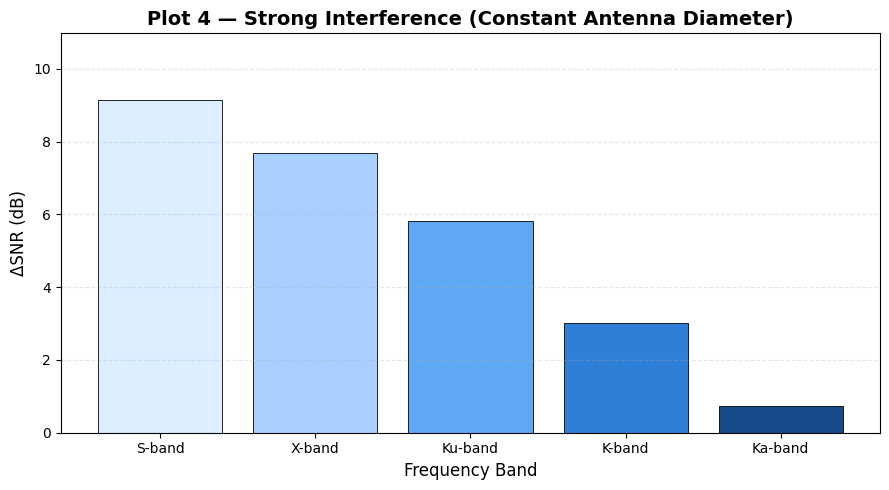

In [6]:
results_strong = []

for band in BAND_NAMES:
    params = VICTIM_BANDS[band].copy()
    params["band_name"] = band

    res = run_multi_entry_rfi_scenario(
        band_params=params,
        interferer_list=INTERFERENCE_SCENARIOS["Strong"],
        time_sim_samples=TIME_SAMPLES,
    )
    results_strong.append(res)

snr_loss_strong = [r["SNR Loss (dB)"] for r in results_strong]

print_table(
    "Plot 4 — Strong Interference (Constant D)",
    f"{'Band':<10} | {'ΔSNR (dB)':>10} | {'C/I (dB)':>10}",
    [
        f"{band:<10} | {r['SNR Loss (dB)']:>10.2f} | {r['C/I_Aggregate (dB)']:>10.2f}"
        for band, r in zip(BAND_NAMES, results_strong)
    ],
)

plot_bar(
    BAND_NAMES,
    snr_loss_strong,
    "ΔSNR (dB)",
    "Plot 4 — Strong Interference (Constant Antenna Diameter)",
)

In [7]:
plt.rcParams.update({
    "font.size": 18,          # base
    "axes.titlesize": 22,     # title
    "axes.labelsize": 20,     # axis labels
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16
})

## Plot 5 — Baseline SNR (No Interference - with sweep)

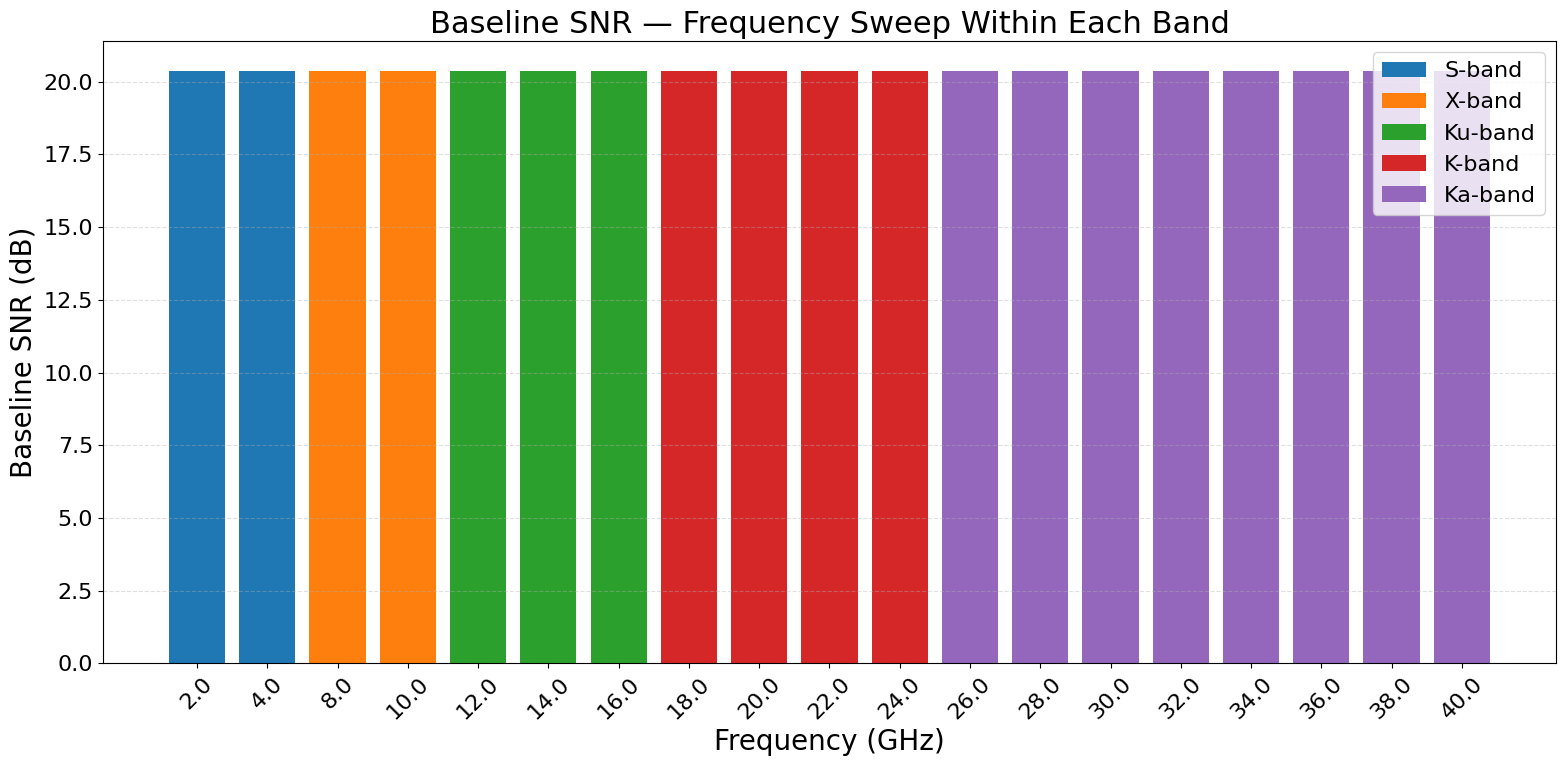

In [8]:
from rfi.scenario import (
    VICTIM_BANDS,
    FREQUENCY_SWEEP_POINTS,
    run_frequency_sweep_rfi_scenario
)

import numpy as np
import matplotlib.pyplot as plt

bands = list(VICTIM_BANDS.keys())

band_colors = {
    "S-band": "#1f77b4",
    "X-band": "#ff7f0e",
    "Ku-band": "#2ca02c",
    "K-band": "#d62728",
    "Ka-band": "#9467bd",
}

plt.figure(figsize=(16,8))

x_cursor = 0
xticks = []
xticklabels = []

for band_name in bands:

    band_params = VICTIM_BANDS[band_name].copy()
    band_params["band_name"] = band_name

    freq_array = FREQUENCY_SWEEP_POINTS[band_name]
    num_freq = len(freq_array)

    result = run_frequency_sweep_rfi_scenario(
        base_params=band_params,
        interferer_list=[],
        freq_values_ghz=freq_array,
    )

    baseline_snr = result["Baseline SNR (dB)"]
    
    first_bar = True
    for j in range(num_freq):
        x_pos = x_cursor + j

        plt.bar(
            x_pos,
            baseline_snr[j],
            width=0.8,
            color=band_colors[band_name],
            label=band_name if first_bar else None
        )

        xticks.append(x_pos)
        xticklabels.append(f"{freq_array[j]}")
        first_bar = False

    x_cursor += num_freq

plt.xticks(xticks, xticklabels, rotation=45)
plt.xlabel("Frequency (GHz)")
plt.ylabel("Baseline SNR (dB)")
plt.title("Baseline SNR — Frequency Sweep Within Each Band")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend(loc='upper right')
plt.tight_layout()

## Save figure
plt.savefig("plot5_baseline_snr_frequency_sweep.pdf", bbox_inches="tight")

plt.show()

## Plot 6 — Weak Interference Sweep

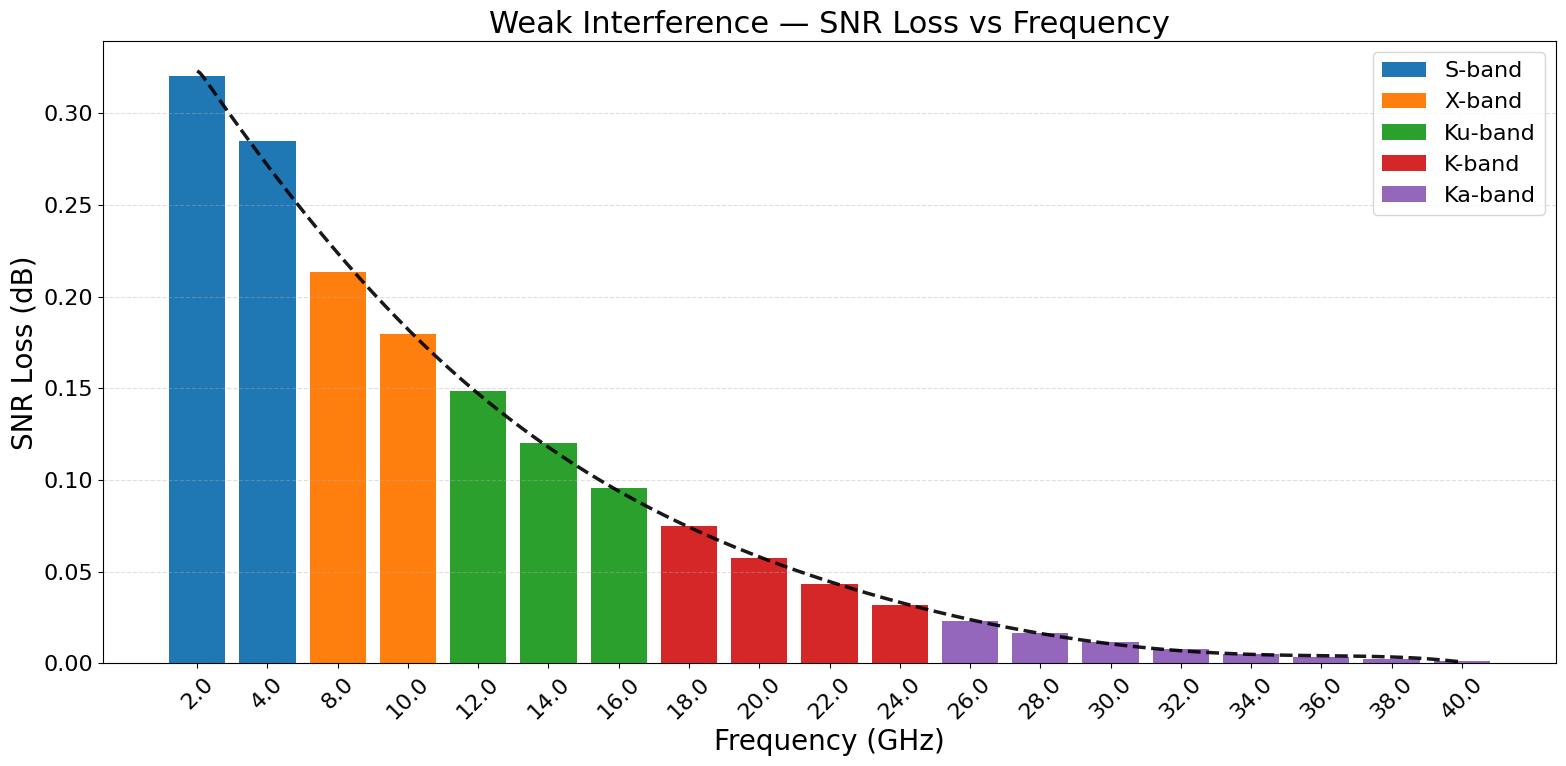

In [9]:
from rfi.scenario import (
    VICTIM_BANDS,
    FREQUENCY_SWEEP_POINTS,
    INTERFERENCE_SCENARIOS,
    run_frequency_sweep_rfi_scenario
)

import numpy as np
import matplotlib.pyplot as plt

bands = list(VICTIM_BANDS.keys())

band_colors = {
    "S-band": "#1f77b4",
    "X-band": "#ff7f0e",
    "Ku-band": "#2ca02c",
    "K-band": "#d62728",
    "Ka-band": "#9467bd",
}

plt.figure(figsize=(16,8))

x_cursor = 0
xticks = []
xticklabels = []

# --- store points for interpolation ---
all_x = []
all_y = []

for band_name in bands:

    band_params = VICTIM_BANDS[band_name].copy()
    band_params["band_name"] = band_name
    freq_array = FREQUENCY_SWEEP_POINTS[band_name]
    num_freq = len(freq_array)

    result = run_frequency_sweep_rfi_scenario(
        base_params=band_params,
        interferer_list=INTERFERENCE_SCENARIOS["Weak"],
        freq_values_ghz=freq_array,
    )

    snr_loss = result["SNR Loss (dB)"] 
    
    first_bar = True
    for j in range(num_freq):
        x_pos = x_cursor + j

        plt.bar(
            x_pos,
            snr_loss[j],
            width=0.8,
            color=band_colors[band_name],
            label=band_name if first_bar else None
        )

        xticks.append(x_pos)
        xticklabels.append(f"{freq_array[j]}")
        all_x.append(x_pos)
        all_y.append(snr_loss[j])
        first_bar = False

    x_cursor += num_freq

# --- SMOOTHING ---
all_x = np.array(all_x)
all_y = np.array(all_y)
idx = np.argsort(all_x)
all_x = all_x[idx]
all_y = all_y[idx]

degree = min(6, len(all_x) - 1)
coeffs = np.polyfit(all_x, all_y, degree)
x_smooth = np.linspace(all_x.min(), all_x.max(), 500)
y_smooth = np.polyval(coeffs, x_smooth)
from scipy.ndimage import gaussian_filter1d
y_smooth = gaussian_filter1d(y_smooth, sigma=1.5)

plt.plot(
    x_smooth, y_smooth,
    linestyle='--', linewidth=2.5, color='black',
    alpha=0.9, zorder=5
)

plt.xticks(xticks, xticklabels, rotation=45)
plt.xlabel("Frequency (GHz)")
plt.ylabel("SNR Loss (dB)")
plt.title("Weak Interference — SNR Loss vs Frequency")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend(loc='upper right')
plt.tight_layout()

## Save figure
plt.savefig("plot6_weak_interference_sweep.pdf", bbox_inches="tight")
plt.show()

## Plot 7 — Moderate Interference Sweep

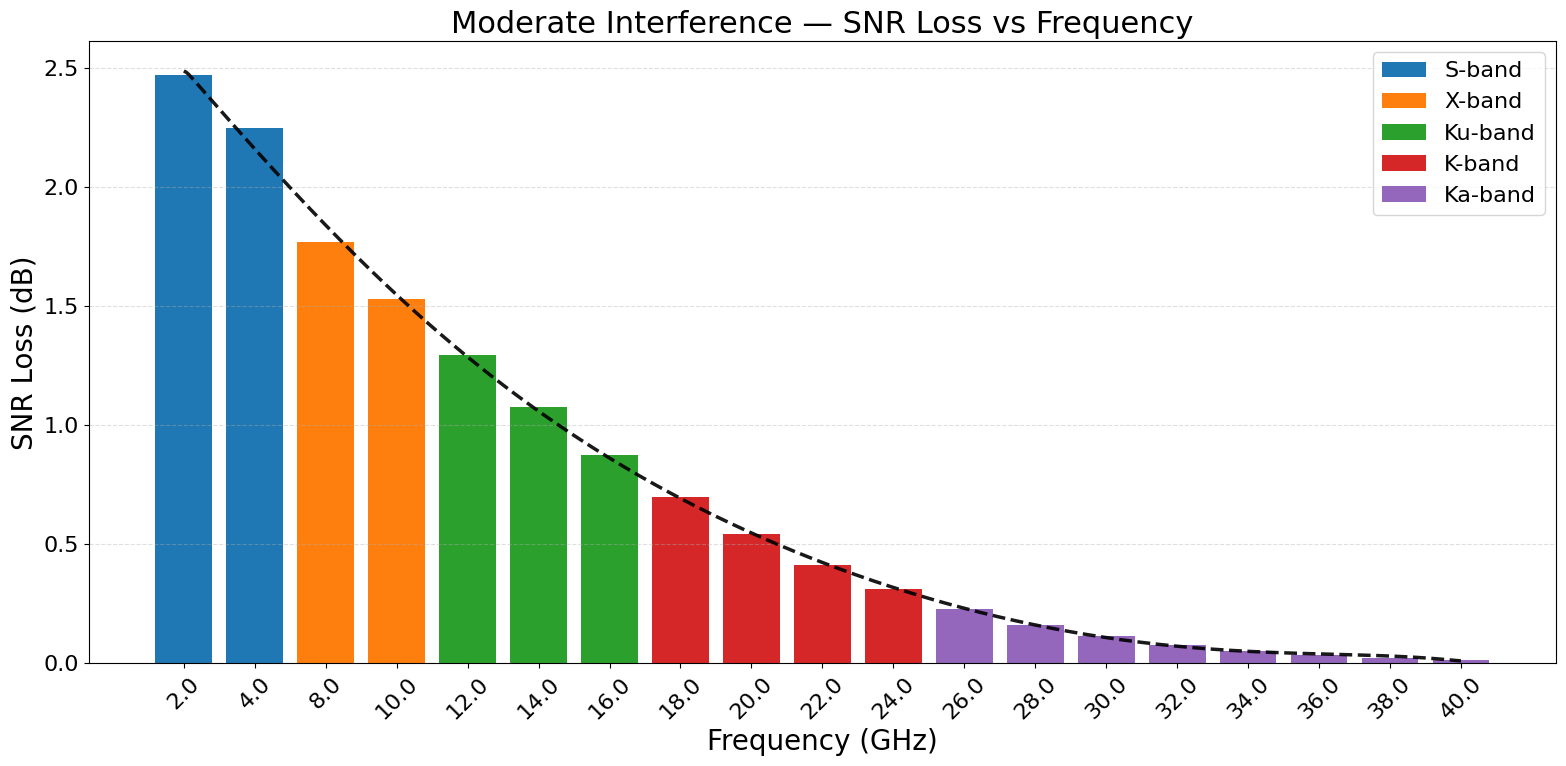

In [10]:
from rfi.scenario import (
    VICTIM_BANDS,
    FREQUENCY_SWEEP_POINTS,
    INTERFERENCE_SCENARIOS,
    run_frequency_sweep_rfi_scenario
)

import numpy as np
import matplotlib.pyplot as plt

bands = list(VICTIM_BANDS.keys())

band_colors = {
    "S-band": "#1f77b4",
    "X-band": "#ff7f0e",
    "Ku-band": "#2ca02c",
    "K-band": "#d62728",
    "Ka-band": "#9467bd",
}

plt.figure(figsize=(16,8))

x_cursor = 0
xticks = []
xticklabels = []

# --- store points for interpolation ---
all_x = []
all_y = []

for band_name in bands:

    band_params = VICTIM_BANDS[band_name].copy()
    band_params["band_name"] = band_name
    freq_array = FREQUENCY_SWEEP_POINTS[band_name]
    num_freq = len(freq_array)

    result = run_frequency_sweep_rfi_scenario(
        base_params=band_params,
        interferer_list=INTERFERENCE_SCENARIOS["Moderate"],
        freq_values_ghz=freq_array,
    )

    snr_loss = result["SNR Loss (dB)"] 
    
    first_bar = True
    for j in range(num_freq):
        x_pos = x_cursor + j

        plt.bar(
            x_pos,
            snr_loss[j],
            width=0.8,
            color=band_colors[band_name],
            label=band_name if first_bar else None 
        )

        xticks.append(x_pos)
        xticklabels.append(f"{freq_array[j]}")
        all_x.append(x_pos)
        all_y.append(snr_loss[j])
        first_bar = False

    x_cursor += num_freq

# --- SMOOTHING  ---
all_x = np.array(all_x)
all_y = np.array(all_y)
idx = np.argsort(all_x)
all_x = all_x[idx]
all_y = all_y[idx]

degree = min(6, len(all_x) - 1)
coeffs = np.polyfit(all_x, all_y, degree)
x_smooth = np.linspace(all_x.min(), all_x.max(), 500)
y_smooth = np.polyval(coeffs, x_smooth)
from scipy.ndimage import gaussian_filter1d
y_smooth = gaussian_filter1d(y_smooth, sigma=1.5)

plt.plot(
    x_smooth, y_smooth,
    linestyle='--', linewidth=2.5, color='black',
    alpha=0.9, zorder=5
)

plt.xticks(xticks, xticklabels, rotation=45)
plt.xlabel("Frequency (GHz)")
plt.ylabel("SNR Loss (dB)")
plt.title("Moderate Interference — SNR Loss vs Frequency")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend(loc='upper right')
plt.tight_layout()

## Save figure
plt.savefig("plot7_moderate_interference_sweep.pdf", bbox_inches="tight")

plt.show()

## Plot 8 — Strong Interference Sweep

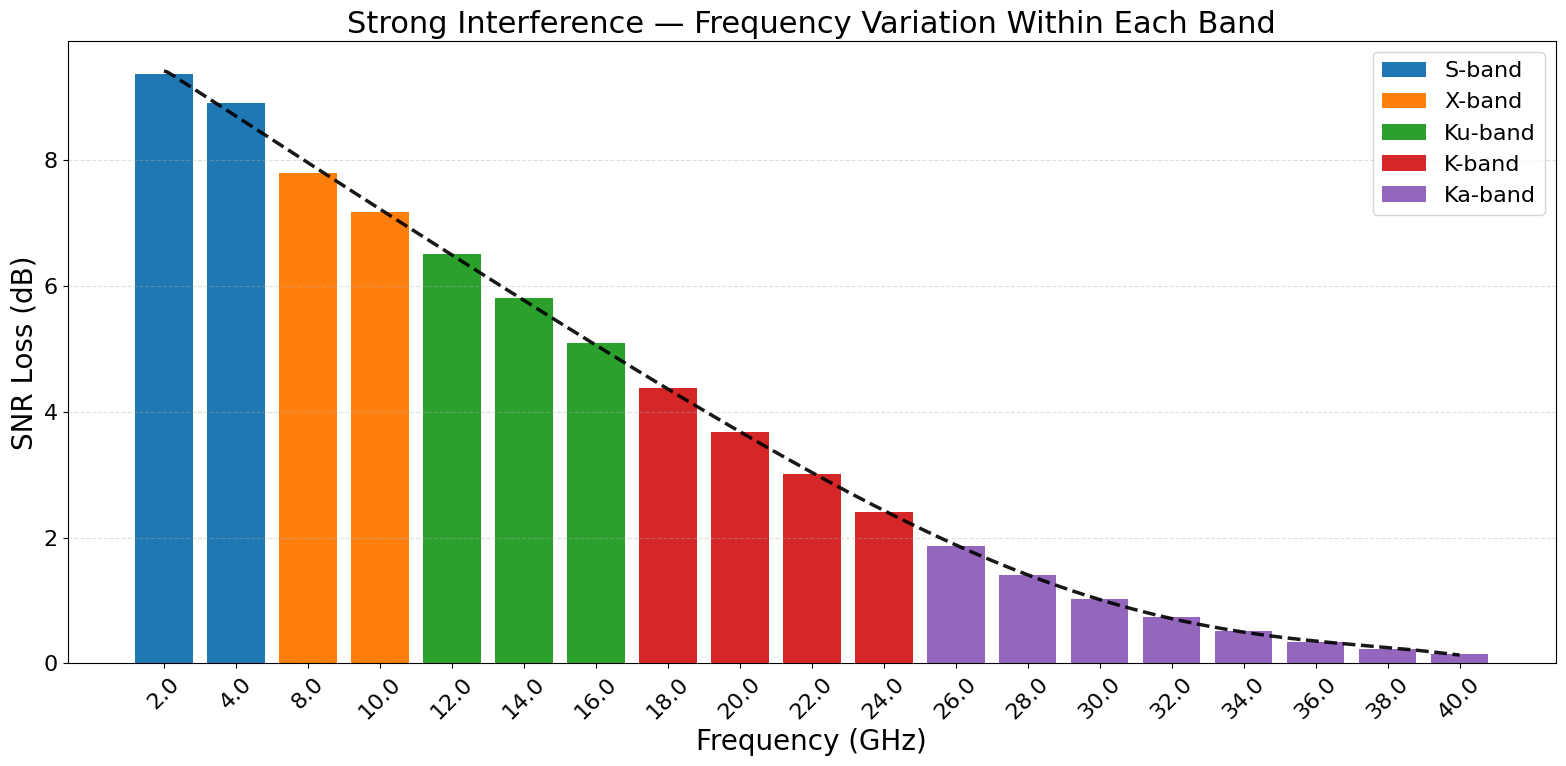

In [11]:
import numpy as np
import matplotlib.pyplot as plt

from rfi.scenario import (
    VICTIM_BANDS,
    FREQUENCY_SWEEP_POINTS,
    INTERFERENCE_SCENARIOS,
    run_frequency_sweep_rfi_scenario
)

bands = list(VICTIM_BANDS.keys())

band_colors = {
    "S-band": "#1f77b4",
    "X-band": "#ff7f0e",
    "Ku-band": "#2ca02c",
    "K-band": "#d62728",
    "Ka-band": "#9467bd",
}

plt.figure(figsize=(16,8))

x_cursor = 0
xticks = []
xticklabels = []

# --- store points for interpolation ---
all_x = []
all_y = []

for band_name in bands:

    base_params = VICTIM_BANDS[band_name].copy()
    base_params["band_name"] = band_name

    freq_array = FREQUENCY_SWEEP_POINTS[band_name]
    num_freq = len(freq_array)

    result = run_frequency_sweep_rfi_scenario(
        base_params=base_params,  
        interferer_list=INTERFERENCE_SCENARIOS["Strong"],
        freq_values_ghz=freq_array,
    )

    snr_loss = result["SNR Loss (dB)"]

    x_positions = np.arange(num_freq) + x_cursor

    plt.bar(
        x_positions,
        snr_loss,
        width=0.8,
        color=band_colors[band_name],
        label=band_name
    )

    xticks.extend(x_positions)
    xticklabels.extend([f"{f}" for f in freq_array])

    # collect points for smooth line
    all_x.extend(x_positions)
    all_y.extend(snr_loss)

    x_cursor += num_freq

# --- SMOOTHING  ---
all_x = np.array(all_x)
all_y = np.array(all_y)

# sort for safety
idx = np.argsort(all_x)
all_x = all_x[idx]
all_y = all_y[idx]

# Create smooth polynomial trend
degree = min(6, len(all_x) - 1)
coeffs = np.polyfit(all_x, all_y, degree)

# Evaluate smooth polynomial
x_smooth = np.linspace(all_x.min(), all_x.max(), 500)
y_smooth = np.polyval(coeffs, x_smooth)

# Gaussian smoothing for a perfect curve
from scipy.ndimage import gaussian_filter1d
y_smooth = gaussian_filter1d(y_smooth, sigma=1.5)

plt.plot(
    x_smooth,
    y_smooth,
    linestyle='--',
    linewidth=2.5,
    color='black',
    alpha=0.9,
    zorder=5
)

plt.xticks(xticks, xticklabels, rotation=45)
plt.xlabel("Frequency (GHz)")
plt.ylabel("SNR Loss (dB)")
plt.title("Strong Interference — Frequency Variation Within Each Band")

plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

## Save figure
plt.savefig("plot8_strong_interference_sweep.pdf", bbox_inches="tight")

plt.show()

## HEATMAP

## Heatmap — SNR Loss vs Frequency and Distance

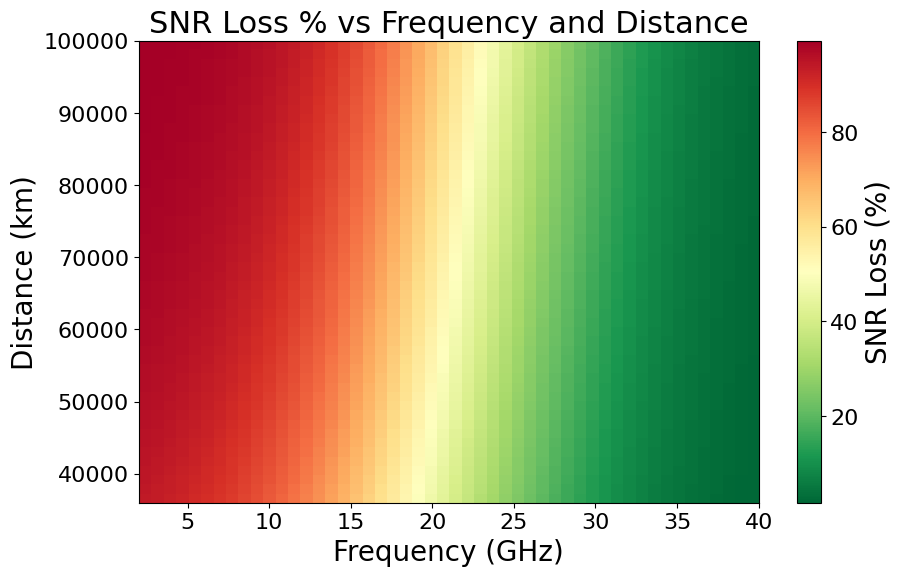

In [12]:
from rfi.scenario import run_distance_frequency_heatmap

freq_grid = np.linspace(2, 40, 50)
distance_grid = np.linspace(36000, 100000, 50)

base_params = VICTIM_BANDS["Ku-band"].copy()
base_params["band_name"] = "Ku-band"

Z = run_distance_frequency_heatmap(
    base_params=base_params,
    interferer_list=INTERFERENCE_SCENARIOS["Moderate"],
    freq_grid=freq_grid,
    distance_grid=distance_grid,
)
Z_percent = (1 - 10 ** (-Z / 10)) * 100  # dB loss to % loss

plt.figure(figsize=(10,6))
im = plt.imshow(Z_percent, aspect="auto", origin="lower",
                extent=[freq_grid[0], freq_grid[-1],
                        distance_grid[0], distance_grid[-1]],
                cmap='RdYlGn_r')

plt.colorbar(label="SNR Loss (%)")
plt.xlabel("Frequency (GHz)")
plt.ylabel("Distance (km)")
plt.title("SNR Loss % vs Frequency and Distance")

## Save figure
#plt.savefig("plot10_SNRLoss_Frequency_Distance.pdf", bbox_inches="tight")

plt.show()

## Moon vs Mars — SNR Loss Comparison

Comparison of interference impact at lunar and Martian distances under different interference strengths.

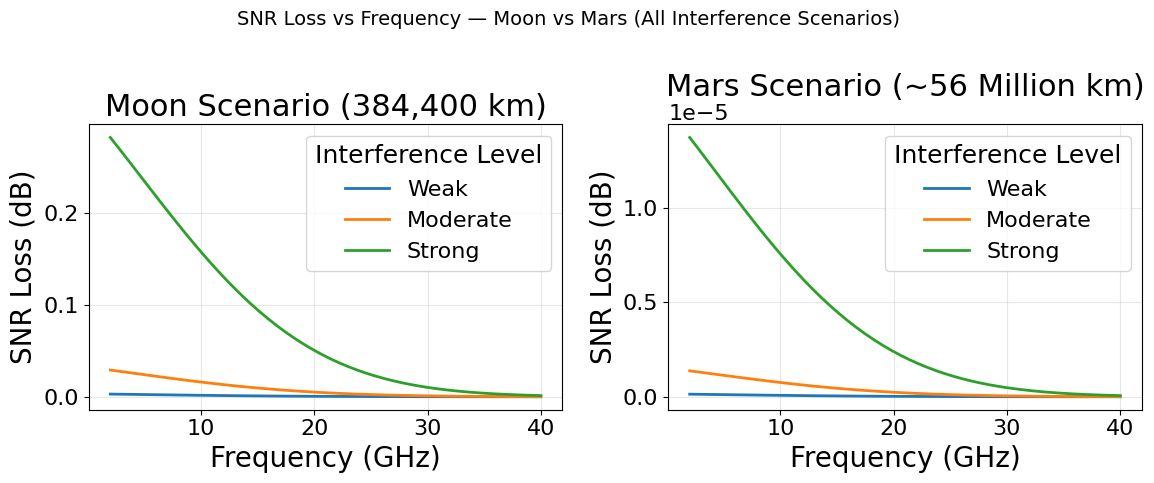

In [13]:
plt.figure(figsize=(12,5))

scenarios = {
    "Weak": 10.0,
    "Moderate": 20.0,
    "Strong": 30.0,
}

# -------------------- MOON ----------------
plt.subplot(1,2,1)

moon_distance = 384400  # km

for name, eirp in scenarios.items():
    snr_loss = []

    for f in freq_grid:
        params = VICTIM_BANDS["Ku-band"].copy()
        params["band_name"] = "Ku-band"  
        params["f_ghz"] = f
        params["d_km"] = moon_distance   # or mars_distance

        interferers = [{
            "EIRP_int_dbw": eirp,
            "d_km": moon_distance,
            "theta_off_axis_deg": 0.5
        }]

        res = run_multi_entry_rfi_scenario(
            band_params=params,
            interferer_list=interferers,
            time_sim_samples=2000,
        )

        snr_loss.append(res["SNR Loss (dB)"])

    plt.plot(freq_grid, snr_loss, linewidth=2, label=name)

plt.xlabel("Frequency (GHz)")
plt.ylabel("SNR Loss (dB)")
plt.title("Moon Scenario (384,400 km)")
plt.legend(title="Interference Level")
plt.grid(alpha=0.3)


# ----------------------- MARS -----------------------
plt.subplot(1,2,2)

mars_distance = 5.6e7  # km

for name, eirp in scenarios.items():
    snr_loss = []

    for f in freq_grid:
        params = VICTIM_BANDS["Ku-band"].copy()
        params["band_name"] = "Ku-band"  
        params["f_ghz"] = f
        params["d_km"] = mars_distance

        interferers = [{
            "EIRP_int_dbw": eirp,
            "d_km": mars_distance,
            "theta_off_axis_deg": 0.5
        }]

        res = run_multi_entry_rfi_scenario(
            band_params=params,
            interferer_list=interferers,
            time_sim_samples=2000,
        )

        snr_loss.append(res["SNR Loss (dB)"])

    plt.plot(freq_grid, snr_loss, linewidth=2, label=name)

plt.xlabel("Frequency (GHz)")
plt.ylabel("SNR Loss (dB)")
plt.title("Mars Scenario (~56 Million km)")
plt.legend(title="Interference Level")
plt.grid(alpha=0.3)


# --------------------------- FINALLY ----------------------------
plt.suptitle("SNR Loss vs Frequency — Moon vs Mars (All Interference Scenarios)", fontsize=14)

plt.tight_layout()

## Save figure
#plt.savefig("plot11_SNRLoss_MoonvsMars.pdf", bbox_inches="tight")

plt.show()

## Heatmap — SNR Loss vs Frequency and Distance (Log Scale)


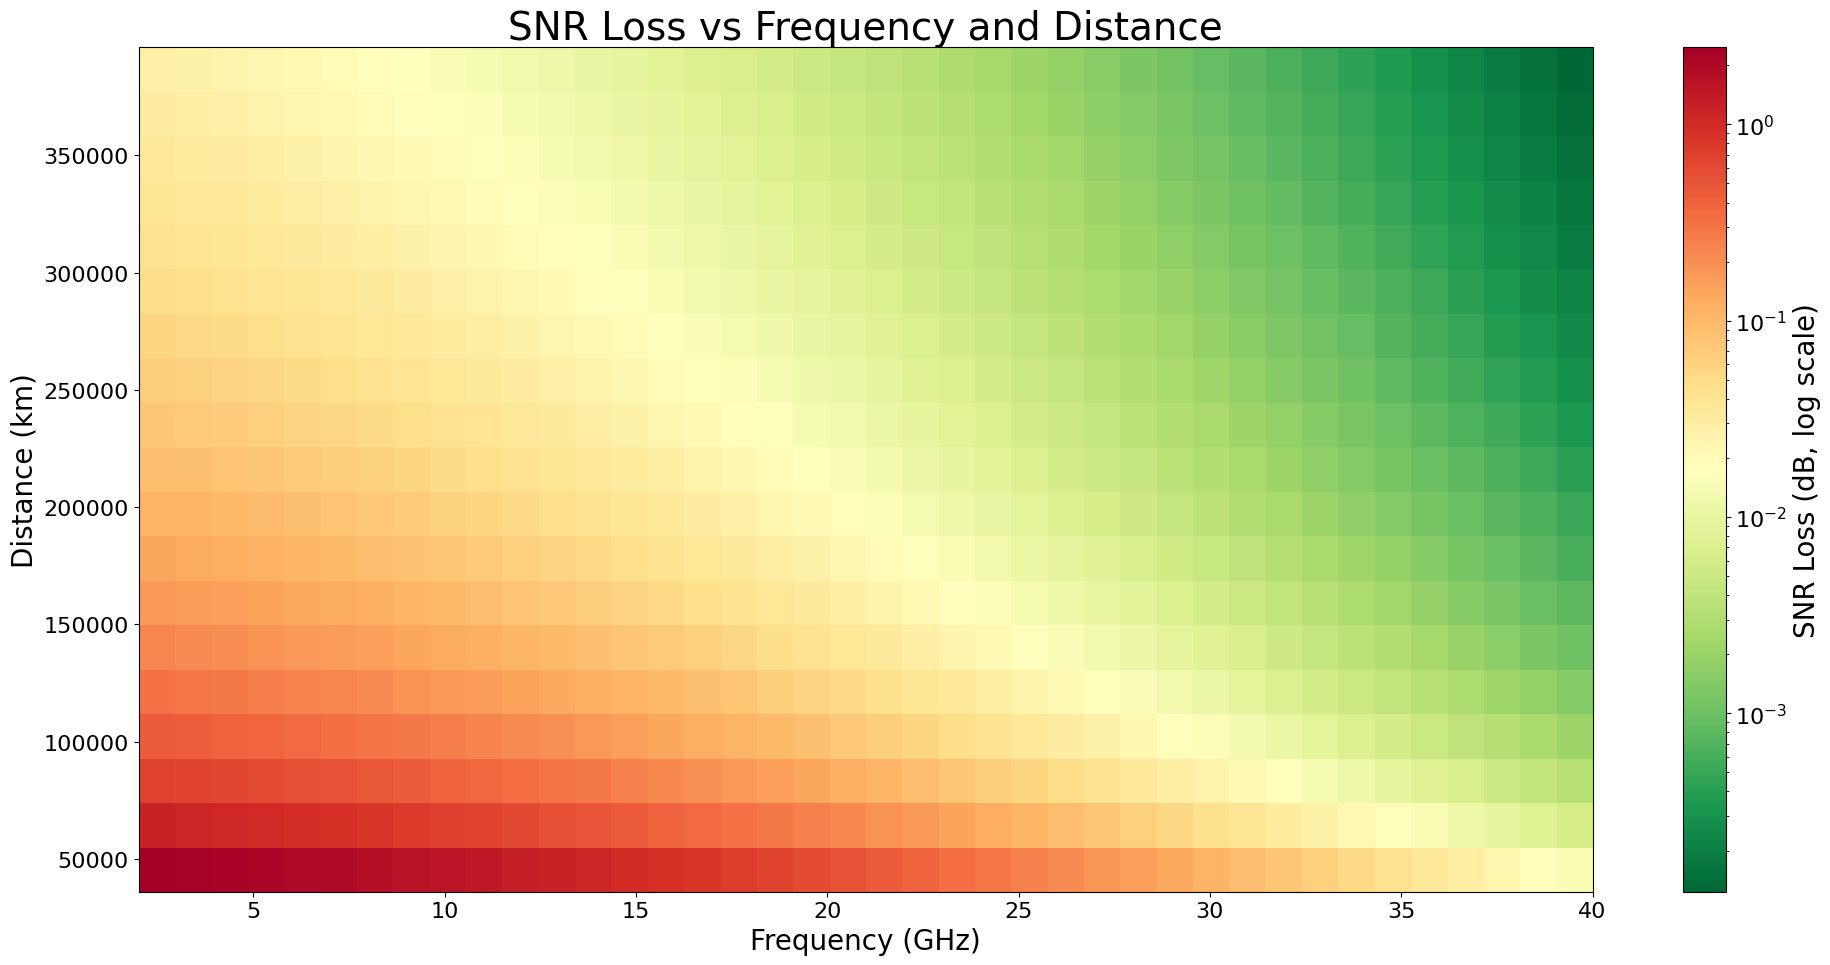

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from rfi.scenario import VICTIM_BANDS, run_multi_entry_rfi_scenario

# ---------------- Frequency grid ----------------
freq_grid = np.linspace(2, 40, 40)  # GHz

# ---------------- Distance grid (two regimes) ----------------
distance_values = np.arange(36000, 400000, 20000)

# ---------------- Base system ----------------
base_params = VICTIM_BANDS["Ku-band"].copy()
base_params["band_name"] = "Ku-band"  

# ---------------- Result matrix ----------------
Z = np.zeros((len(distance_values), len(freq_grid)))

# ---------------- Core computation ----------------
for i, d in enumerate(distance_values):
    for j, f in enumerate(freq_grid):

        params = base_params.copy()
        params["f_ghz"] = f
        params["d_km"] = d

        interferers = [{
            "EIRP_int_dbw": 20.0,
            "d_km": d,
            "theta_off_axis_deg": 0.5
        }]

        res = run_multi_entry_rfi_scenario(
            band_params=params,
            interferer_list=interferers,
        )

        Z[i, j] = max(res["SNR Loss (dB)"], 1e-6)

# ---------------- Plot ----------------
plt.figure(figsize=(20,10))

im = plt.imshow(
    Z,
    aspect="auto",
    origin="lower",
    extent=[freq_grid[0], freq_grid[-1],
            distance_values[0], distance_values[-1]],
    cmap="RdYlGn_r",
    norm=LogNorm(vmin=Z.min(), vmax=Z.max())  # log scale
)

cbar = plt.colorbar(im)
cbar.set_label("SNR Loss (dB, log scale)", fontsize=20)
cbar.ax.tick_params(labelsize=16)

plt.xlabel("Frequency (GHz)")
plt.ylabel("Distance (km)")
plt.title("SNR Loss vs Frequency and Distance", fontsize=28)

plt.tight_layout()

## Save figure
plt.savefig("plot12_SNRLoss_Frequency_Distance.pdf", bbox_inches="tight")

plt.show()

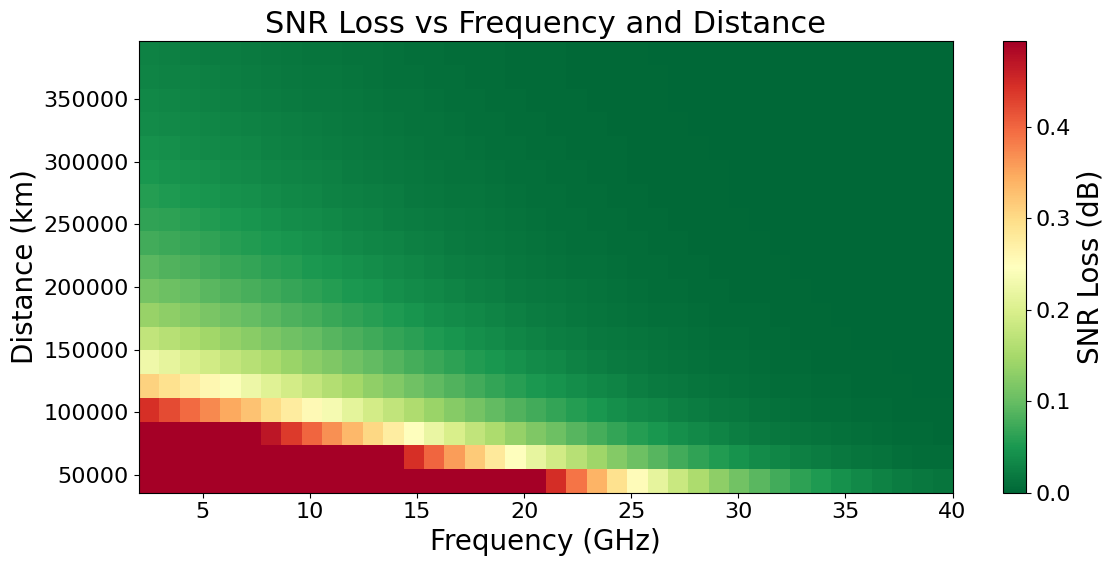

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from rfi.scenario import VICTIM_BANDS, run_multi_entry_rfi_scenario

freqgrid = np.linspace(2, 40, 40)
distancevalues = np.arange(36000, 400000, 20000)

baseparams = VICTIM_BANDS["Ku-band"].copy()
Z = np.zeros((len(distancevalues), len(freqgrid)))

for i, d in enumerate(distancevalues):
    for j, f in enumerate(freqgrid):
        params = baseparams.copy()
        params["f_ghz"] = float(f)
        params["d_km"] = float(d)

        interferers = [{
            "EIRP_int_dbw": 20.0,
            "d_km": float(d),
            "theta_off_axis_deg": 0.5,
            "sigma_db": 6.0,
            "duty_cycle": 1.0,
        }]

        res = run_multi_entry_rfi_scenario(
            band_params=params,
            interferer_list=interferers,
            time_sim_samples=1000,
        )
        Z[i, j] = max(res["SNR Loss (dB)"], 0.0)

plt.figure(figsize=(12, 6))
im = plt.imshow(
    Z,
    aspect="auto",
    origin="lower",
    extent=[freqgrid[0], freqgrid[-1], distancevalues[0], distancevalues[-1]],
    cmap="RdYlGn_r",
    vmin=0,
    vmax=np.percentile(Z, 95)   # or try 90, 92, 97
)
plt.colorbar(im, label="SNR Loss (dB)")
plt.xlabel("Frequency (GHz)")
plt.ylabel("Distance (km)")
plt.title("SNR Loss vs Frequency and Distance")
plt.tight_layout()
plt.savefig("plot12_SNRLoss_Frequency_Distance_linear.png", dpi=300, bbox_inches="tight")
plt.savefig("plot12_SNRLoss_Frequency_Distance_linear.pdf", bbox_inches="tight")
plt.show()


# Curve Equations ------

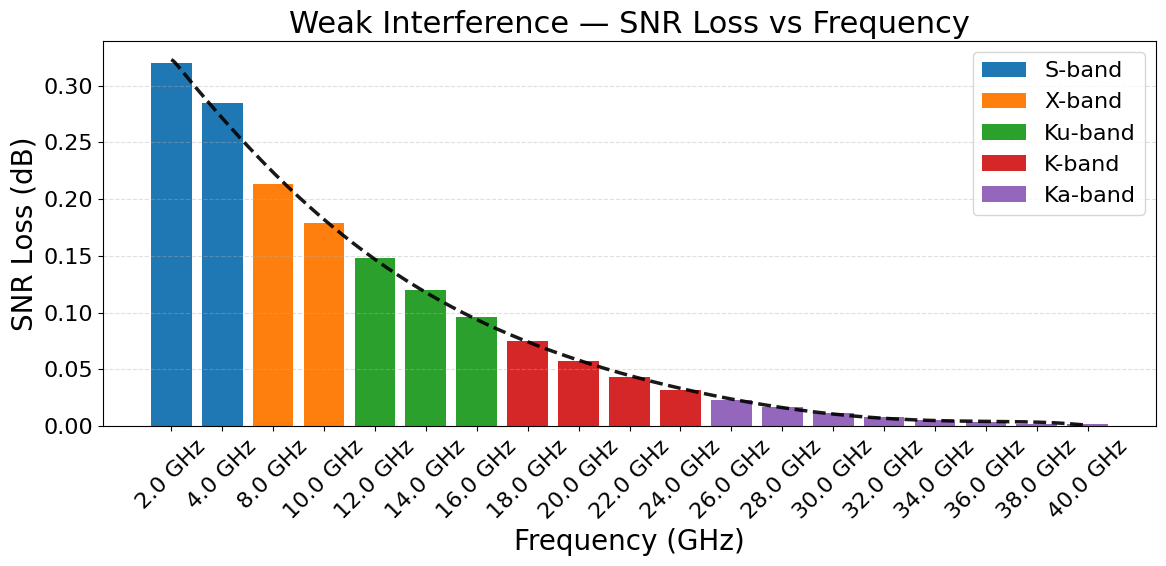


Equation of the Plot:
SNR_loss(f) = 0.336 * exp(-0.218 * f)


In [16]:
from rfi.scenario import (
    VICTIM_BANDS,
    FREQUENCY_SWEEP_POINTS,
    INTERFERENCE_SCENARIOS,
    run_frequency_sweep_rfi_scenario
)

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.optimize import curve_fit

bands = list(VICTIM_BANDS.keys())

band_colors = {
    "S-band": "#1f77b4",
    "X-band": "#ff7f0e",
    "Ku-band": "#2ca02c",
    "K-band": "#d62728",
    "Ka-band": "#9467bd",
}

plt.figure(figsize=(12,6))

x_cursor = 0
xticks = []
xticklabels = []

all_x = []
all_y = []

# -------- DATA --------
for band_name in bands:

    band_params = VICTIM_BANDS[band_name].copy()
    band_params["band_name"] = band_name
    freq_array = FREQUENCY_SWEEP_POINTS[band_name]

    result = run_frequency_sweep_rfi_scenario(
        base_params=band_params,
        interferer_list=INTERFERENCE_SCENARIOS["Weak"],
        freq_values_ghz=freq_array,
    )

    snr_loss = result["SNR Loss (dB)"] 
    
    for j in range(len(freq_array)):
        x_pos = x_cursor + j

        plt.bar(
            x_pos,
            snr_loss[j],
            width=0.8,
            color=band_colors[band_name],
            label=band_name if j == 0 else None
        )

        xticks.append(x_pos)
        xticklabels.append(f"{freq_array[j]} GHz")
        all_x.append(x_pos)
        all_y.append(snr_loss[j])

    x_cursor += len(freq_array)

# -------- SORT --------
all_x = np.array(all_x)
all_y = np.array(all_y)
idx = np.argsort(all_x)
all_x = all_x[idx]
all_y = all_y[idx]

# -------- POLYNOMIAL  --------
degree = min(6, len(all_x) - 1)
coeffs = np.polyfit(all_x, all_y, degree)

x_smooth = np.linspace(all_x.min(), all_x.max(), 500)
y_poly = np.polyval(coeffs, x_smooth)
y_poly_smooth = gaussian_filter1d(y_poly, sigma=1.5)

plt.plot(
    x_smooth, y_poly_smooth,
    linestyle='--', linewidth=2.5, color='black',
    alpha=0.9, zorder=5,
    
)

# -------- EXPONENTIAL (compute only, don't plot) --------
def exp_decay(x, a, b):
    return a * np.exp(-b * x)

popt_exp, _ = curve_fit(exp_decay, all_x, all_y, p0=(max(all_y), 0.05))

# -------- FORMAT --------
plt.xticks(xticks, xticklabels, rotation=45)
plt.xlabel("Frequency (GHz)")
plt.ylabel("SNR Loss (dB)")
plt.title("Weak Interference — SNR Loss vs Frequency")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend(loc='upper right')
plt.tight_layout()

#plt.savefig("plot6_weak_interference_sweep.pdf", bbox_inches="tight")
plt.show()

# -------- FINAL EQUATION --------
print("\nEquation of the Plot:")
print(f"SNR_loss(f) = {popt_exp[0]:.3f} * exp(-{popt_exp[1]:.3f} * f)")

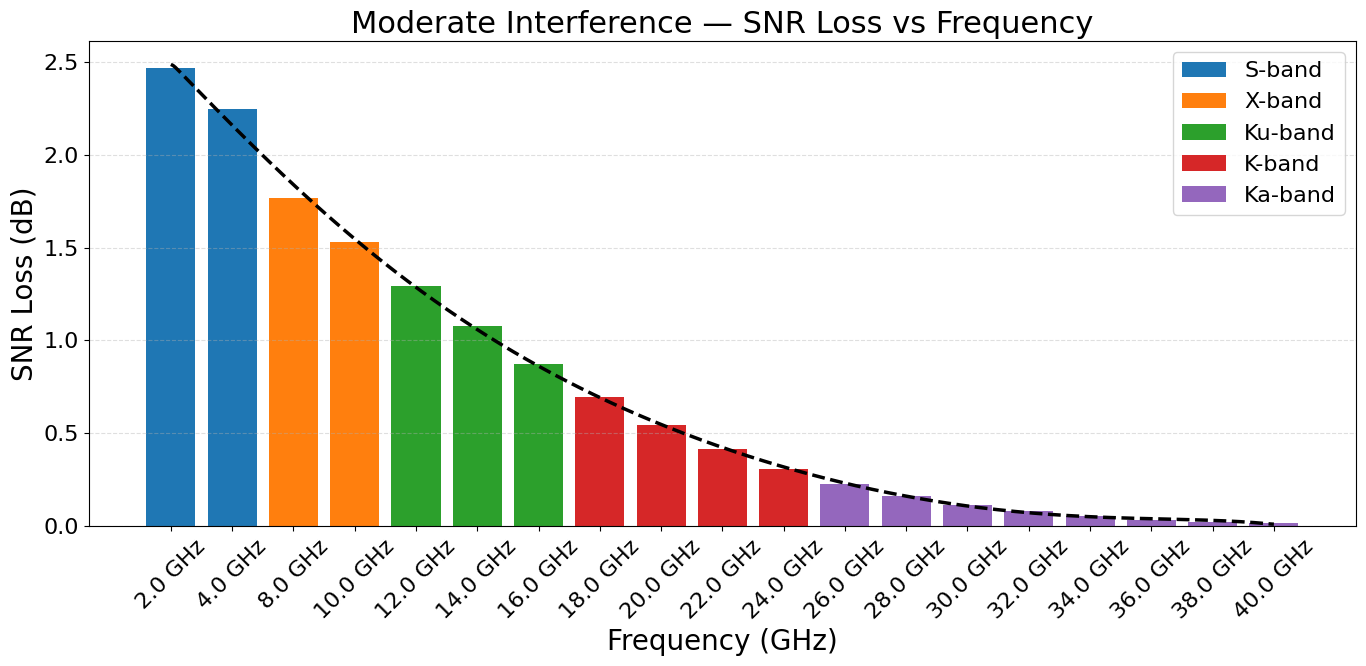


Equation of the Plot:
SNR_loss(f) = 2.627 * exp(-0.196 * f)


In [17]:
from rfi.scenario import (
    VICTIM_BANDS, FREQUENCY_SWEEP_POINTS, INTERFERENCE_SCENARIOS, run_frequency_sweep_rfi_scenario
)
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.optimize import curve_fit

bands = list(VICTIM_BANDS.keys())
band_colors = {"S-band": "#1f77b4", "X-band": "#ff7f0e", "Ku-band": "#2ca02c", 
               "K-band": "#d62728", "Ka-band": "#9467bd"}

plt.figure(figsize=(14,7))
x_cursor = 0
xticks, xticklabels = [], []
all_x, all_y = [], []

# Collect data
for band_name in bands:
    band_params = VICTIM_BANDS[band_name].copy()
    band_params["band_name"] = band_name
    freq_array = FREQUENCY_SWEEP_POINTS[band_name]
    num_freq = len(freq_array)
    
    result = run_frequency_sweep_rfi_scenario(
        base_params=band_params,
        interferer_list=INTERFERENCE_SCENARIOS["Moderate"],
        freq_values_ghz=freq_array
    )
    snr_loss = result["SNR Loss (dB)"]
    
    for j in range(num_freq):
        x_pos = x_cursor + j
        plt.bar(x_pos, snr_loss[j], width=0.8,
                color=band_colors[band_name],
                label=band_name if j == 0 else None)
        
        xticks.append(x_pos)
        xticklabels.append(f"{freq_array[j]} GHz")
        all_x.append(x_pos)
        all_y.append(snr_loss[j])

    x_cursor += num_freq

# Sort data
all_x = np.array(all_x)
all_y = np.array(all_y)
idx = np.argsort(all_x)
all_x, all_y = all_x[idx], all_y[idx]

# -------- Polynomial  --------
degree = min(6, len(all_x) - 1)
coeffs = np.polyfit(all_x, all_y, degree)

x_smooth = np.linspace(all_x.min(), all_x.max(), 500)
y_poly = np.polyval(coeffs, x_smooth)
y_poly_smooth = gaussian_filter1d(y_poly, sigma=1.5)

plt.plot(
    x_smooth, y_poly_smooth,
    'k--', linewidth=2.5, zorder=5,
    
)

# -------- Exponential (compute ONLY) --------
def exp_decay(x, a, b):
    return a * np.exp(-b * x)

popt_exp, _ = curve_fit(exp_decay, all_x, all_y, p0=(max(all_y), 0.05))

# Formatting
plt.xticks(xticks, xticklabels, rotation=45)
plt.xlabel("Frequency (GHz)")
plt.ylabel("SNR Loss (dB)")
plt.title("Moderate Interference — SNR Loss vs Frequency")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# -------- Final equation ONLY --------
print(f"\nEquation of the Plot:")
print(f"SNR_loss(f) = {popt_exp[0]:.3f} * exp(-{popt_exp[1]:.3f} * f)")

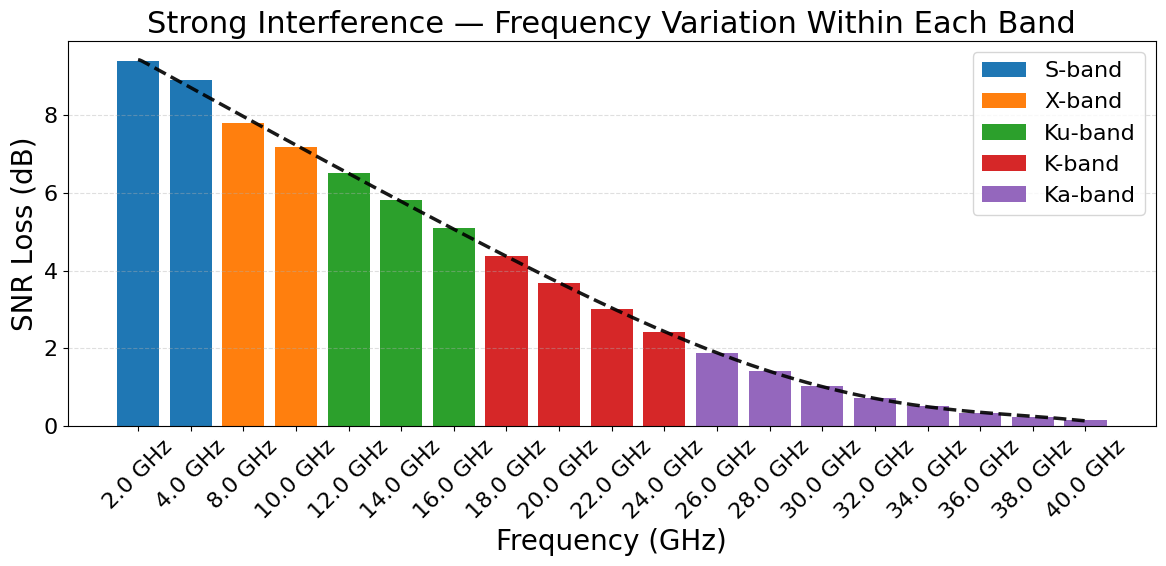


Equation of the Plot:
SNR_loss(f) = 10.370 * exp(-0.143 * f)


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.optimize import curve_fit

from rfi.scenario import (
    VICTIM_BANDS,
    FREQUENCY_SWEEP_POINTS,
    INTERFERENCE_SCENARIOS,
    run_frequency_sweep_rfi_scenario
)

bands = list(VICTIM_BANDS.keys())

band_colors = {
    "S-band": "#1f77b4",
    "X-band": "#ff7f0e",
    "Ku-band": "#2ca02c",
    "K-band": "#d62728",
    "Ka-band": "#9467bd",
}

plt.figure(figsize=(12,6))

x_cursor = 0
xticks = []
xticklabels = []

all_x = []
all_y = []

# -------- DATA --------
for band_name in bands:

    base_params = VICTIM_BANDS[band_name].copy()
    base_params["band_name"] = band_name

    freq_array = FREQUENCY_SWEEP_POINTS[band_name]

    result = run_frequency_sweep_rfi_scenario(
        base_params=base_params,
        interferer_list=INTERFERENCE_SCENARIOS["Strong"],
        freq_values_ghz=freq_array,
    )

    snr_loss = result["SNR Loss (dB)"]

    x_positions = np.arange(len(freq_array)) + x_cursor

    plt.bar(
        x_positions,
        snr_loss,
        width=0.8,
        color=band_colors[band_name],
        label=band_name
    )

    xticks.extend(x_positions)
    xticklabels.extend([f"{f} GHz" for f in freq_array])

    all_x.extend(x_positions)
    all_y.extend(snr_loss)

    x_cursor += len(freq_array)

# -------- SORT --------
all_x = np.array(all_x)
all_y = np.array(all_y)
idx = np.argsort(all_x)
all_x = all_x[idx]
all_y = all_y[idx]

# -------- POLYNOMIAL  --------
degree = min(6, len(all_x) - 1)
coeffs = np.polyfit(all_x, all_y, degree)

x_smooth = np.linspace(all_x.min(), all_x.max(), 500)
y_poly = np.polyval(coeffs, x_smooth)
y_poly_smooth = gaussian_filter1d(y_poly, sigma=1.5)

plt.plot(
    x_smooth,
    y_poly_smooth,
    linestyle='--',
    linewidth=2.5,
    color='black',
    alpha=0.9,
    zorder=5,
    
)

# -------- EXPONENTIAL (compute only) --------
def exp_decay(x, a, b):
    return a * np.exp(-b * x)

popt_exp, _ = curve_fit(exp_decay, all_x, all_y, p0=(max(all_y), 0.05))

# -------- FORMAT --------
plt.xticks(xticks, xticklabels, rotation=45)
plt.xlabel("Frequency (GHz)")
plt.ylabel("SNR Loss (dB)")
plt.title("Strong Interference — Frequency Variation Within Each Band")

plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

#plt.savefig("plot8_strong_interference_sweep.pdf", bbox_inches="tight")
plt.show()

# -------- FINAL EQUATION --------
print("\nEquation of the Plot:")
print(f"SNR_loss(f) = {popt_exp[0]:.3f} * exp(-{popt_exp[1]:.3f} * f)")

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from rfi.scenario import VICTIM_BANDS, run_multi_entry_rfi_scenario

# Common frequency grid
freq_grid = np.linspace(2, 40, 40)  # GHz

# Interference scenarios
scenarios = {
    "Weak": 10.0,
    "Moderate": 20.0,
    "Strong": 30.0,
}

# Base system
base_params = VICTIM_BANDS["Ku-band"].copy()
base_params["band_name"] = "Ku-band"

# Distances
moon_distance = 384400        # km
mars_distance = 5.6e7         # km

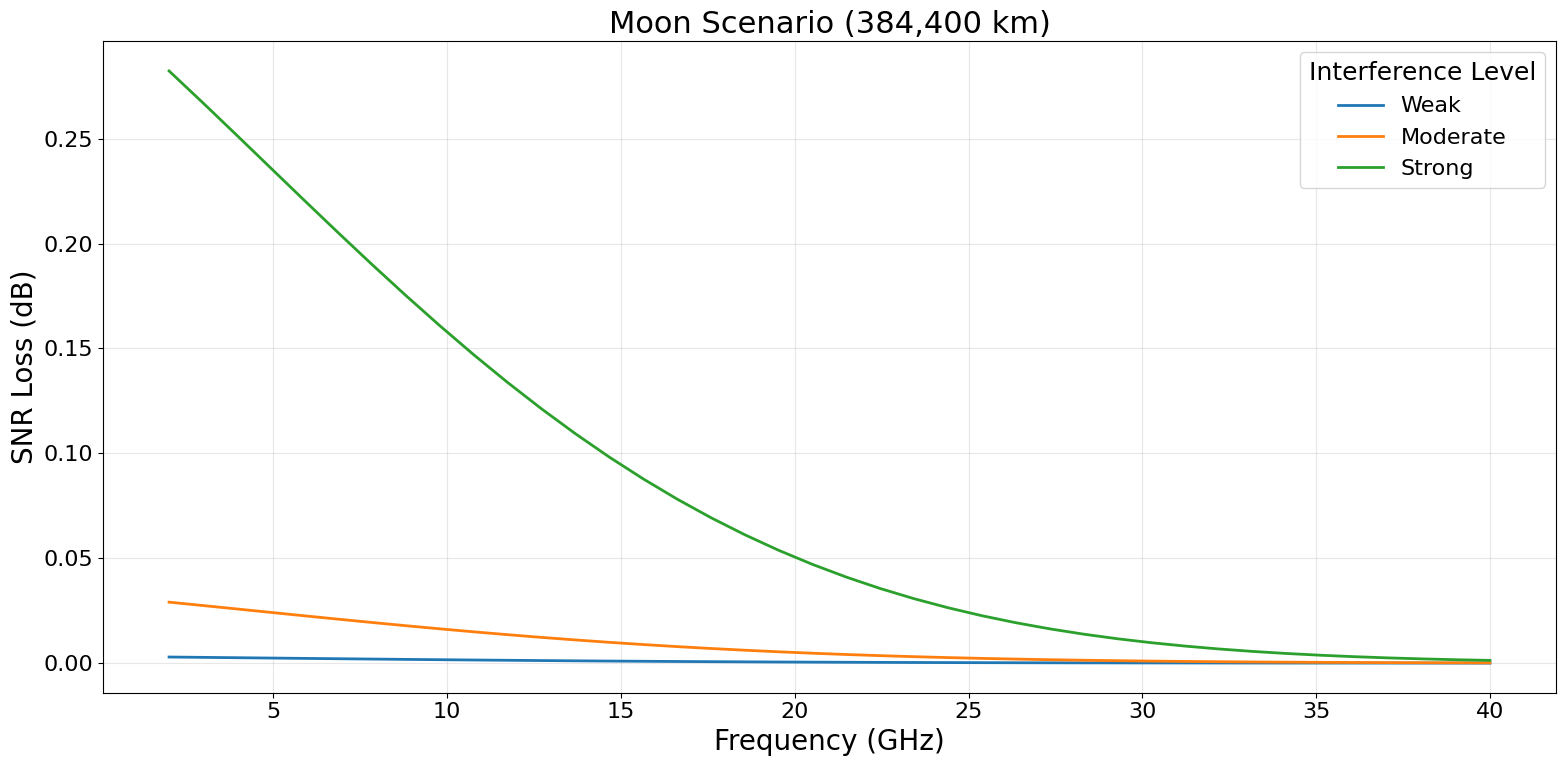

In [20]:
# Figure 6 — SNR loss for Moon scenario

plt.figure(figsize=(16,8))

for name, eirp in scenarios.items():
    snr_loss = []
    for f in freq_grid:
        params = base_params.copy()
        params["f_ghz"] = f
        params["d_km"] = moon_distance

        interferers = [{
            "EIRP_int_dbw": eirp,
            "d_km": moon_distance,
            "theta_off_axis_deg": 0.5
        }]

        res = run_multi_entry_rfi_scenario(
            band_params=params,
            interferer_list=interferers,
            time_sim_samples=2000,
        )
        snr_loss.append(res["SNR Loss (dB)"])

    plt.plot(freq_grid, snr_loss, linewidth=2, label=name)

plt.xlabel("Frequency (GHz)")
plt.ylabel("SNR Loss (dB)")
plt.title("Moon Scenario (384,400 km)")
plt.legend(title="Interference Level")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("plot11_moon_snr.pdf", bbox_inches="tight")
# plt.savefig("plot11_moon_snr.png", dpi=600, bbox_inches="tight")

plt.show()

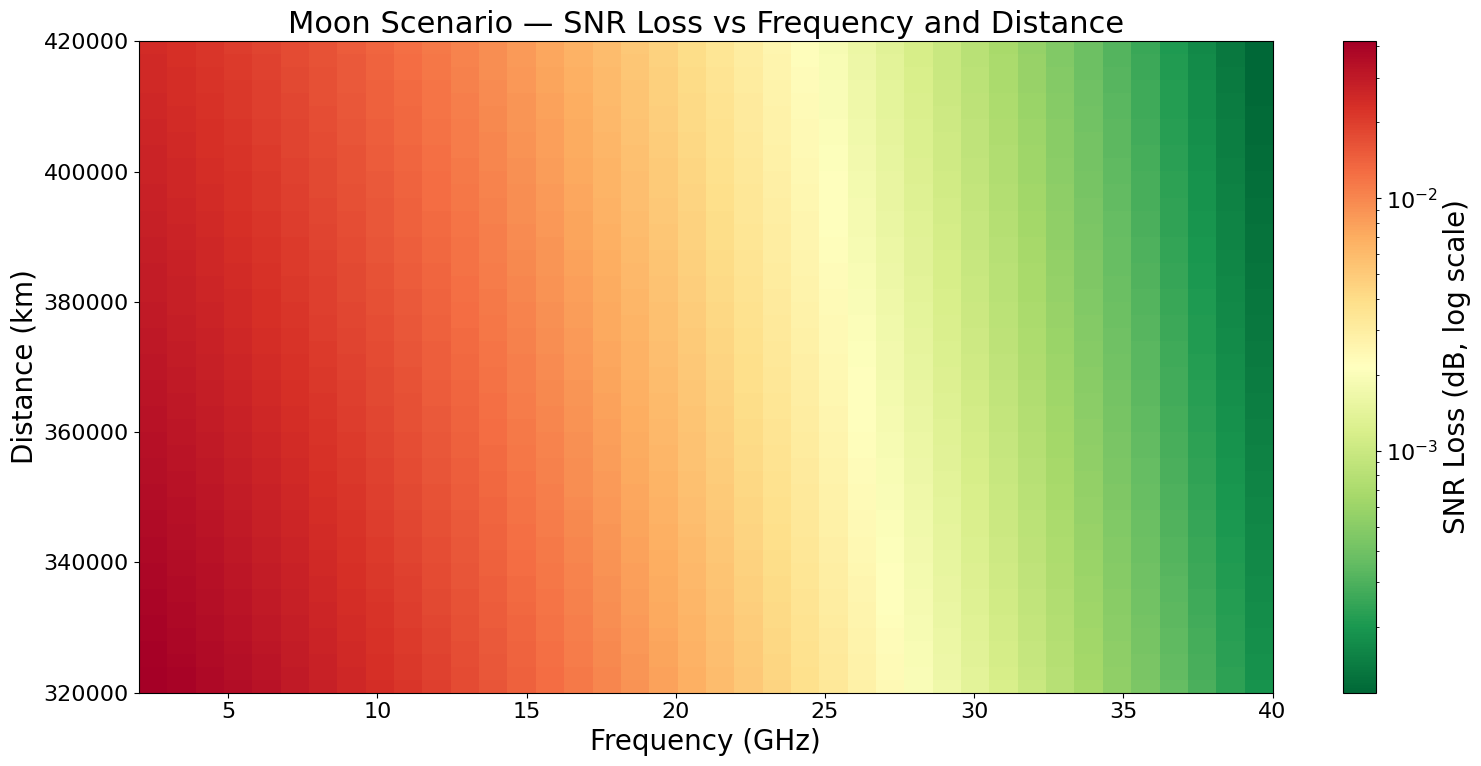

In [21]:
# Figure 7 — Moon distance heatmap

moon_distance_grid = np.linspace(3.2e5, 4.2e5, 50)  # 320,000 km to 420,000 km
Z_moon = np.zeros((len(moon_distance_grid), len(freq_grid)))

for i, d in enumerate(moon_distance_grid):
    for j, f in enumerate(freq_grid):
        params = base_params.copy()
        params["f_ghz"] = f
        params["d_km"] = d

        interferers = [{
            "EIRP_int_dbw": scenarios["Moderate"],
            "d_km": d,
            "theta_off_axis_deg": 0.5
        }]

        res = run_multi_entry_rfi_scenario(
            band_params=params,
            interferer_list=interferers,
            time_sim_samples=2000,
        )

        Z_moon[i, j] = max(res["SNR Loss (dB)"], 1e-6)

plt.figure(figsize=(16,8))
im = plt.imshow(
    Z_moon,
    aspect="auto",
    origin="lower",
    extent=[freq_grid[0], freq_grid[-1], moon_distance_grid[0], moon_distance_grid[-1]],
    cmap="RdYlGn_r",
    norm=LogNorm(vmin=Z_moon.min(), vmax=Z_moon.max())
)

cbar = plt.colorbar(im)
cbar.set_label("SNR Loss (dB, log scale)")
plt.xlabel("Frequency (GHz)")
plt.ylabel("Distance (km)")
plt.title("Moon Scenario — SNR Loss vs Frequency and Distance")
plt.tight_layout()

plt.savefig("plot12_moon_distance_heatmap.pdf", bbox_inches="tight")
# plt.savefig("plot12_moon_distance_heatmap.png", dpi=600, bbox_inches="tight")

plt.show()

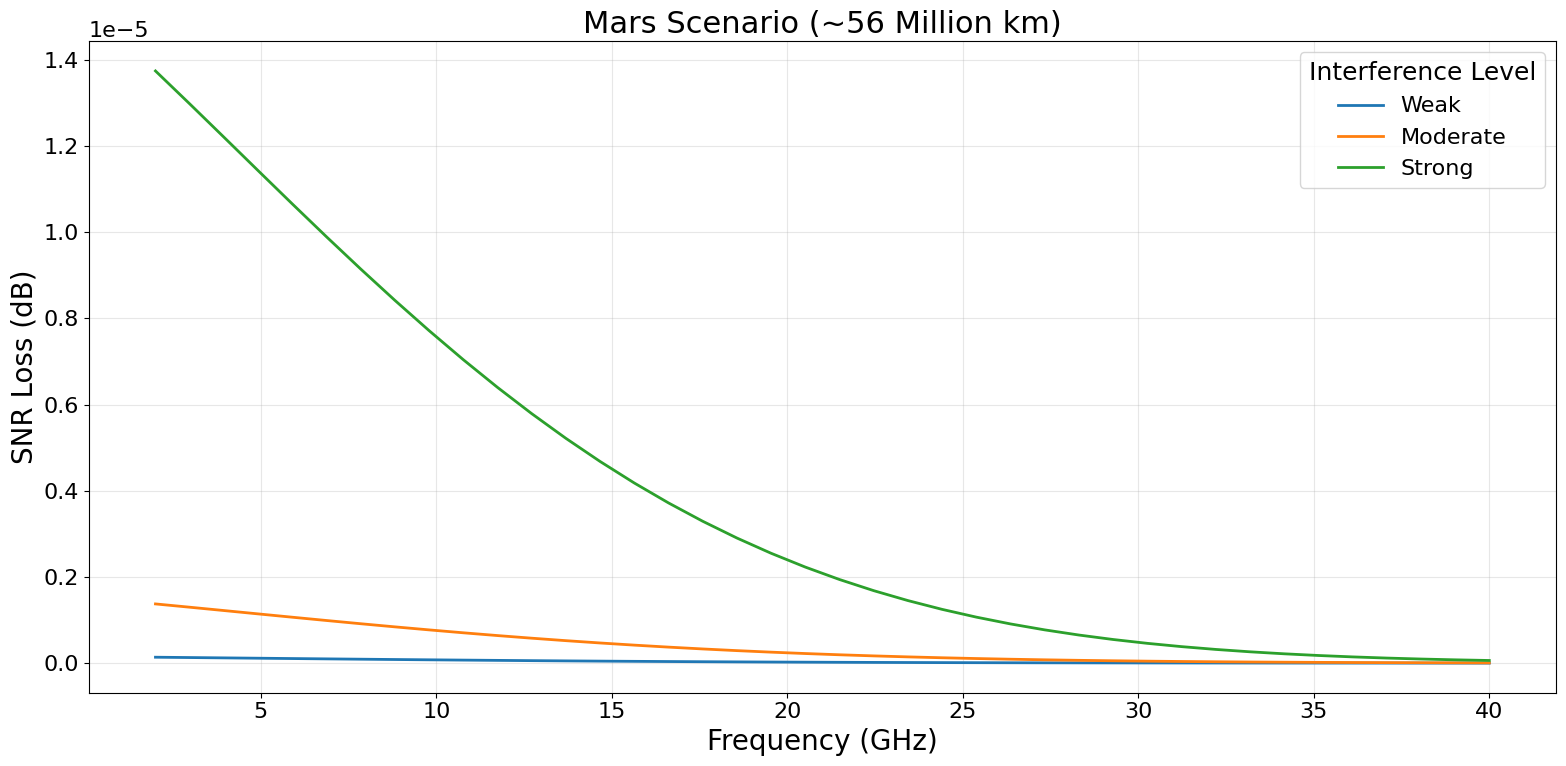

In [22]:
# Figure 8 — SNR loss for Mars scenario

plt.figure(figsize=(16,8))

for name, eirp in scenarios.items():
    snr_loss = []
    for f in freq_grid:
        params = base_params.copy()
        params["f_ghz"] = f
        params["d_km"] = mars_distance

        interferers = [{
            "EIRP_int_dbw": eirp,
            "d_km": mars_distance,
            "theta_off_axis_deg": 0.5
        }]

        res = run_multi_entry_rfi_scenario(
            band_params=params,
            interferer_list=interferers,
            time_sim_samples=2000,
        )
        snr_loss.append(res["SNR Loss (dB)"])

    plt.plot(freq_grid, snr_loss, linewidth=2, label=name)

plt.xlabel("Frequency (GHz)")
plt.ylabel("SNR Loss (dB)")
plt.title("Mars Scenario (~56 Million km)")
plt.legend(title="Interference Level")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("plot13_mars_snr.pdf", bbox_inches="tight")
# plt.savefig("plot13_mars_snr.png", dpi=600, bbox_inches="tight")

plt.show()

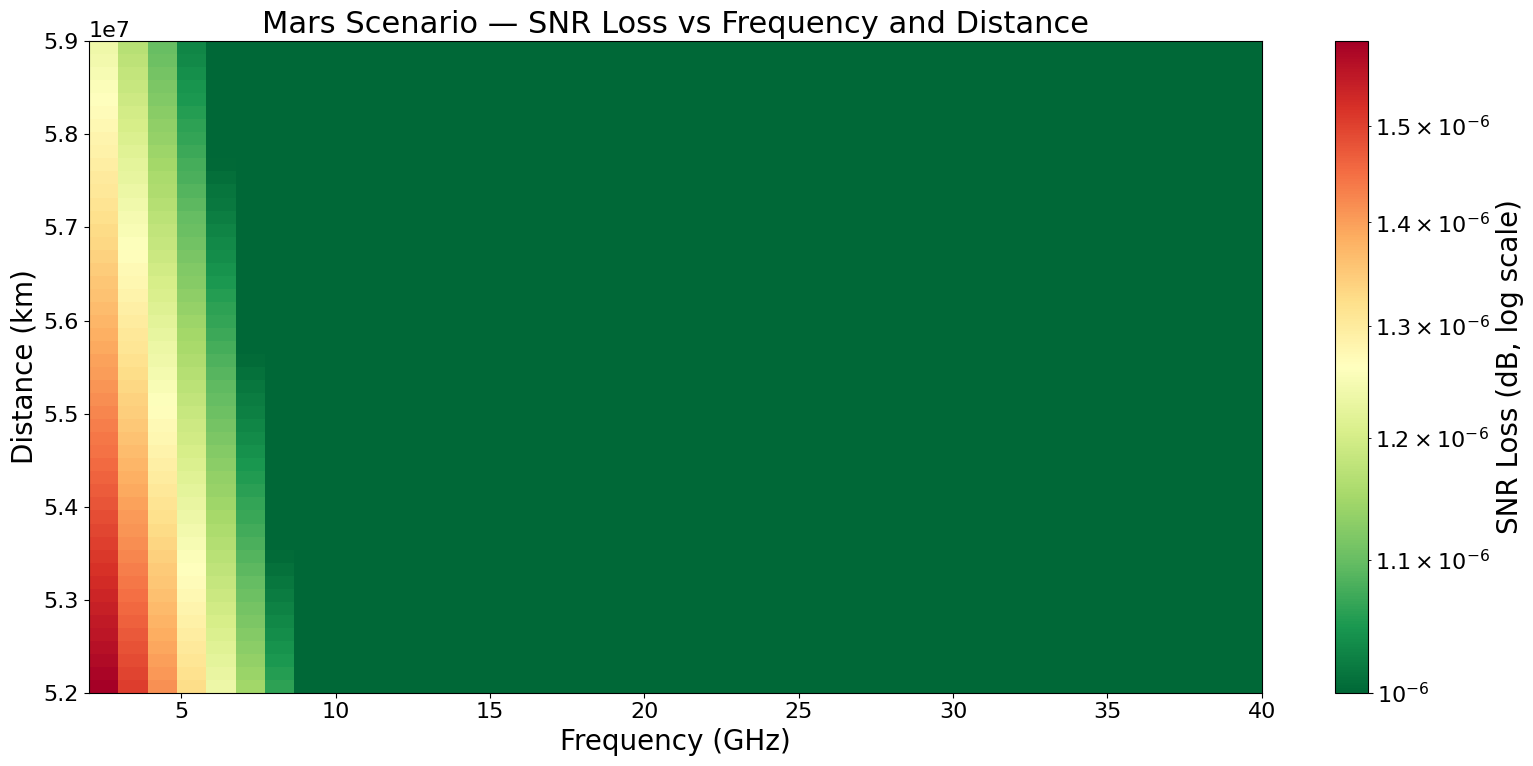

In [23]:
# Figure 9 — Mars distance heatmap

mars_distance_grid = np.linspace(5.2e7, 5.9e7, 50)  # 52 million km to 59 million km
Z_mars = np.zeros((len(mars_distance_grid), len(freq_grid)))

for i, d in enumerate(mars_distance_grid):
    for j, f in enumerate(freq_grid):
        params = base_params.copy()
        params["f_ghz"] = f
        params["d_km"] = d

        interferers = [{
            "EIRP_int_dbw": scenarios["Moderate"],
            "d_km": d,
            "theta_off_axis_deg": 0.5
        }]

        res = run_multi_entry_rfi_scenario(
            band_params=params,
            interferer_list=interferers,
            time_sim_samples=2000,
        )

        Z_mars[i, j] = max(res["SNR Loss (dB)"], 1e-6)

plt.figure(figsize=(16,8))
im = plt.imshow(
    Z_mars,
    aspect="auto",
    origin="lower",
    extent=[freq_grid[0], freq_grid[-1], mars_distance_grid[0], mars_distance_grid[-1]],
    cmap="RdYlGn_r",
    norm=LogNorm(vmin=Z_mars.min(), vmax=Z_mars.max())
)

cbar = plt.colorbar(im)
cbar.set_label("SNR Loss (dB, log scale)")
plt.xlabel("Frequency (GHz)")
plt.ylabel("Distance (km)")
plt.title("Mars Scenario — SNR Loss vs Frequency and Distance")
plt.tight_layout()

plt.savefig("plot14_mars_distance_heatmap.pdf", bbox_inches="tight")
# plt.savefig("plot14_mars_distance_heatmap.png", dpi=600, bbox_inches="tight")

plt.show()